# <span style="color:black; font-weight:bold;">Cross-modal alignment Xenium_V1_mouse_pup-HE Tutorial</span>
+ <span style="color:black; font-weight:bold;">Creator</span>: Bingjie Dai (17516970902@163.com)
+ <span style="color:black; font-weight:bold;">Date of Creation</span>: 6.23.2026
+ <span style="color:black; font-weight:bold;">Date of Last Modification</span>: 6.23.2026
+ <span style="color:black; font-weight:bold;">Download</span>: Cross-modal Xenium_V1_mouse_pup-HE data used in the tutorial are available at [Million_Mouse_Tissue.h5ad](https://drive.google.com/file/d/1kh65BE245umkQbX2O-WNaoNY0tq0RALz/view?usp=sharing) and [Xenium_V1_mouse_pup_he_emb.h5ad](https://drive.google.com/file/d/1oR3vk_Sw_QeZNopho7TEtxzcwsZEoH8W/view?usp=sharing). The raw data is from [10xGENOMICS](https://www.10xgenomics.com/) 
In this tutorial we apply MAPS to align Xenium to HE mouse_pup dataset

<span style="color:black; font-weight:bold;">The dataset have:</span>   
+ <span style="color:black; font-weight:bold;">Xenium(ST)</span>: 1,355,849 cells and 379 genes   
+ <span style="color:black; font-weight:bold;">HE(Cellpose-SAM)</span>: 1,183,626 cells 

In [1]:
from MAPS.align import Rigid_alignment
from MAPS.utils import set_seed,rotate_and_translate_spatial,create_new_color_dict,plot_aligned_adata_on_if
import scanpy as sc
import pandas as pd
import torch
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [3]:
set_seed(7)

## <span style="color:black; font-weight:bold;">Loading Cross-modal Xenium_V1_mouse_pup data (Xenium and HE-Cellpose-SAM)</span>
#### To ensure the accuracy of the scaling factor, we recommend using the slice with a larger initial coordinate range as the target_adata for learning the scaling factor.

In [4]:
source_adata=sc.read_h5ad('/home/dbj/SpaLP/Tutorialdata/Million_Mouse_Tissue.h5ad')
source_adata.obs['batch']='Xenium'

target_adata=sc.read_h5ad('/home/dbj/LPcross/Data/HERNA/Xenium_V1_mouse_pup_he_emb.h5ad')
target_adata.obs['batch']='HE-Cellpose-SAM'

### Translation the source xenium data 

In [5]:
rotate_and_translate_spatial(source_adata,angle_deg=0,dx=68000,dy=48000)

## <span style="color:black; font-weight:bold;">Spatial mapping of the mouse_pup before alignment</span> 

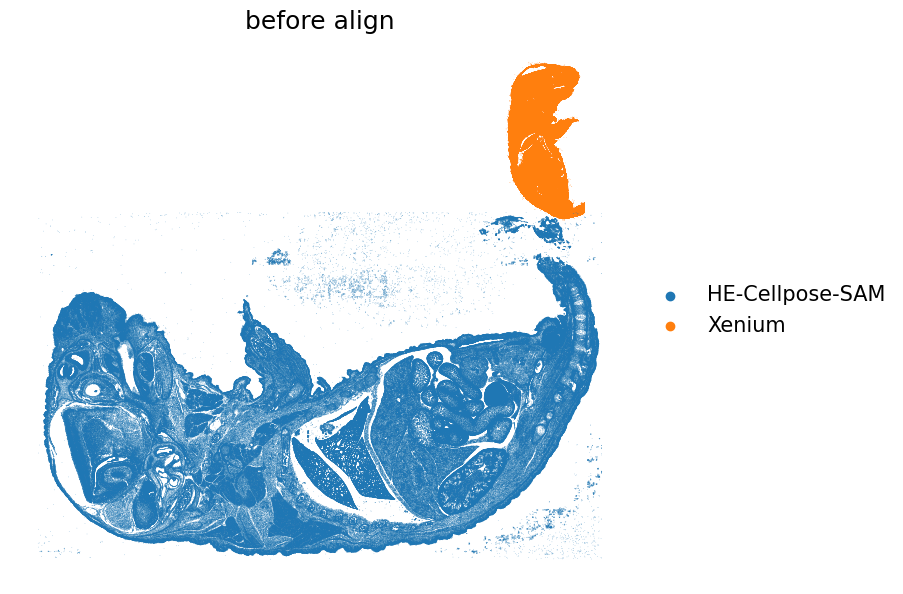

In [6]:
import matplotlib.pyplot as plt
import copy
plt.rcParams['figure.figsize'] = (8,7.1)
plt.rcParams['font.size'] = 15

adata=sc.concat([source_adata,target_adata],join='inner')
sc.pl.embedding(adata=adata, basis='spatial',color='batch',title='before align',size=0.5,frameon=False)

## <span style="color:black; font-weight:bold;">Align the slices using MAPS</span> 
### <span style="color:black; font-weight:bold;">Training parameters</span> 
+ epochs: Training ephchs  
+ device: Training device  
+ sample_size: The number of samples used for alignment  
+ enable_scale: Whether to learn the scaling factor?  

### <span style="color:black; font-weight:bold;">Output</span>   
+ aligned_spatial: The coordinates of the source slices after alignment  
+ theta_deg: Angle of rotation  
+ translation: Translation matrix  
+ scale: Scaling factor 

In [7]:
%%time
source = source_adata.obsm['spatial'].astype(np.float32) 
target = target_adata.obsm['spatial'].astype(np.float32)  

aligned_spatial, theta_deg, translation,scale= Rigid_alignment(source, target, epochs=4000, sample_size=20000,enable_scale=True,device=device)
source_adata.obsm['spatial'] = aligned_spatial

Scanning angles to find best starting angle...


Global Align: 100%|█████████████████████████████| 4000/4000 [01:16<00:00, 52.35it/s, Loss=152.37, Scale=3.652, Rot=89.94°, Trans=(-32624.9, -40927.9)]


Peak GPU memory usage: 4.928 GB
Scale factor: 3.652, Rotation angle: 89.98°, Translation (x, y): (-32623.92, -40925.21)
CPU times: user 57.7 s, sys: 24.1 s, total: 1min 21s
Wall time: 1min 24s


## <span style="color:black; font-weight:bold;">Spatial mapping of the mouse pup after alignment</span>

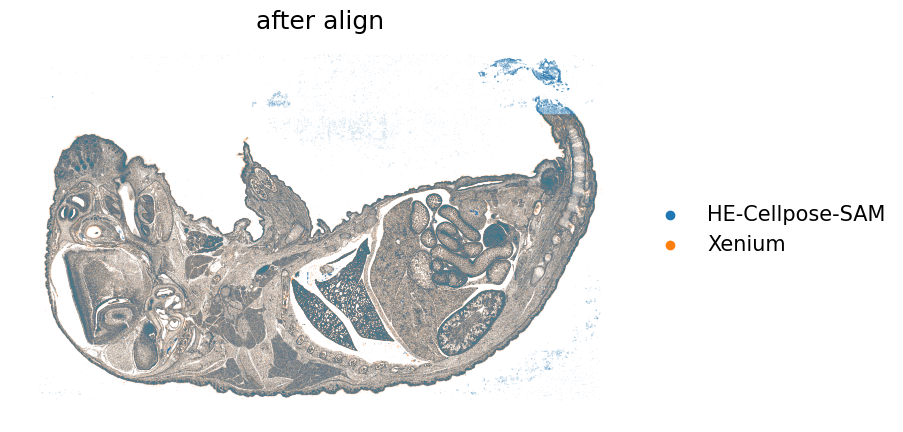

In [8]:
import matplotlib.pyplot as plt
import copy
plt.rcParams['figure.figsize'] = (8,5)
plt.rcParams['font.size'] = 15

adata=sc.concat([source_adata,target_adata],join='inner')
sc.pl.embedding(adata=adata, basis='spatial',color='batch',size=0.3,title='after align',alpha=0.4,frameon=False)